 Section 1 — Environment Setup

In [ ]:
# Install packages not pre-installed in Colab
!pip install category_encoders xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.6 MB/s eta 0:00:00


In [ ]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import category_encoders as ce

# XGBoost (with sklearn fallback)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost loaded.")
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    HAS_XGB = False
    print("XGBoost not found — using sklearn GradientBoostingClassifier.")

# Global seeds & plot style
np.random.seed(42)
plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "font.size"         : 11,
})

print("All libraries loaded successfully.")
print(f"  pandas  {pd.__version__}  |  numpy {np.__version__}")

XGBoost loaded.
All libraries loaded successfully.
  pandas  2.2.2  |  numpy 2.0.2


 Section 2 — Load Data

In [ ]:
RAW_PATH = '/content/DOHMH_New_York_City_Restaurant_Inspection_Results_20260404.csv'

df_raw = pd.read_csv(RAW_PATH, engine='python', on_bad_lines='warn')

print(f"Loaded  : {len(df_raw):,} rows  x  {df_raw.shape[1]} columns")
print(f"File    : {RAW_PATH}")
print(f"Memory  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded  : 295,995 rows  x  27 columns
File    : /content/DOHMH_New_York_City_Restaurant_Inspection_Results_20260404.csv
Memory  : 388.3 MB


In [ ]:
# Preview first 3 rows
df_raw.head(3)

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50001776,THE PALM,Queens,NaN,JFK INTERNATIONAL AIRPORT,11430.0,7187514798,American,02/07/2024,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50184004,ZHIBO WANG,Manhattan,37,WEST 26 STREET,10010.0,9176989963,NaN,01/01/1900,NaN,...,NaN,40.744172,-73.989902,105.0,3.0,5800.0,1015634.0,1.008280e+09,MN13,POINT (-73.989902411653 40.744171548431)
2,50180715,GREENPOINT COMEDY CLUB,Brooklyn,66,GREENPOINT AVENUE,11222.0,3474575227,NaN,01/01/1900,NaN,...,NaN,40.729790,-73.958384,301.0,33.0,56500.0,3064791.0,3.025620e+09,BK76,POINT (-73.958384433116 40.729790115358)


In [ ]:
# Missing value summary
miss = pd.DataFrame({
    'dtype'      : df_raw.dtypes,
    'non_null'   : df_raw.notnull().sum(),
    'missing'    : df_raw.isnull().sum(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
})
print("Columns with missing data:")
print(miss[miss['missing'] > 0].to_string())

Columns with missing data:
                         dtype  non_null  missing  missing_pct
DBA                     object    295994        1          0.0
BUILDING                object    295008      987          0.3
STREET                  object    295989        6          0.0
ZIPCODE                float64    292829     3166          1.1
PHONE                   object    295922       73          0.0
CUISINE DESCRIPTION     object    292470     3525          1.2
ACTION                  object    292520     3475          1.2
VIOLATION CODE          object    290220     5775          2.0
VIOLATION DESCRIPTION   object    290220     5775          2.0
SCORE                  float64    279125    16870          5.7
GRADE                   object    145856   150139         50.7
GRADE DATE              object    136442   159553         53.9
INSPECTION TYPE         object    292520     3475          1.2
Latitude               float64    294368     1627          0.5
Longitude              float

Section 3 — Data Cleaning & Preprocessing

Steps performed:
- Parse INSPECTION DATE and GRADE DATE as datetime
- Remove rows with sentinel date 1900-01-01 (known placeholder in DOHMH system)
- Filter to Cycle Inspections only — Pre-permit and Administrative inspections are separate regulatory processes
- Standardise text columns (strip whitespace, title case)
- Remove unknown borough code '0'
- Cap SCORE at the 99th percentile to reduce outlier influence

In [ ]:
df = df_raw.copy()

# Parse dates
df['INSPECTION DATE'] = pd.to_datetime(df['INSPECTION DATE'], errors='coerce')
df['GRADE DATE']      = pd.to_datetime(df['GRADE DATE'],      errors='coerce')

print(f"Rows before cleaning : {len(df):,}")

# Remove sentinel dates (1900-01-01 is a DOHMH system placeholder)
df = df[df['INSPECTION DATE'] > '1901-01-01'].copy()
print(f"After sentinel date removal  : {len(df):,} rows  ({len(df_raw)-len(df):,} dropped)")

# Keep only Cycle Inspections
cycle_mask = df['INSPECTION TYPE'].str.contains('Cycle Inspection', na=False)
df = df[cycle_mask].copy()
print(f"After Cycle Inspection filter: {len(df):,} rows  |  {df['CAMIS'].nunique():,} unique restaurants")

# Standardise text
for col in ['BORO', 'CUISINE DESCRIPTION', 'CRITICAL FLAG', 'GRADE', 'ACTION']:
    df[col] = df[col].astype(str).str.strip().str.title()

# Remove unknown borough
df = df[df['BORO'] != '0'].copy()
print(f"After BORO cleanup           : {len(df):,} rows")

# Cap SCORE at 99th percentile
SCORE_CAP = df['SCORE'].quantile(0.99)
df['SCORE'] = df['SCORE'].clip(upper=SCORE_CAP)
print(f"\nSCORE capped at p99 = {SCORE_CAP:.0f}")
print(df['SCORE'].describe().round(2))

Rows before cleaning : 295,995
After sentinel date removal  : 292,520 rows  (3,475 dropped)
After Cycle Inspection filter: 219,203 rows  |  22,048 unique restaurants
After BORO cleanup           : 218,994 rows

SCORE capped at p99 = 83
count    218994.00
mean         23.74
std          16.51
min           0.00
25%          12.00
50%          20.00
75%          31.00
max          83.00
Name: SCORE, dtype: float64


In [ ]:
# Confirm CRITICAL FLAG distribution after cleaning
print("CRITICAL FLAG value counts:")
print(df['CRITICAL FLAG'].value_counts())
print()
print("INSPECTION TYPE breakdown:")
print(df['INSPECTION TYPE'].value_counts())

CRITICAL FLAG value counts:
CRITICAL FLAG
Critical          121924
Not Critical       96513
Not Applicable       557
Name: count, dtype: int64

INSPECTION TYPE breakdown:
INSPECTION TYPE
Cycle Inspection / Initial Inspection              156022
Cycle Inspection / Re-inspection                    58969
Cycle Inspection / Reopening Inspection              2625
Cycle Inspection / Compliance Inspection             1297
Cycle Inspection / Second Compliance Inspection        81
Name: count, dtype: int64


 Section 4 — Exploratory Data Analysis (EDA)

Four visualisations:
1. Critical flag distribution (row level)
2. Inspection score distribution by borough
3. Critical violation rate trend 2010–2026
4. Top 10 cuisine types by critical violation rate

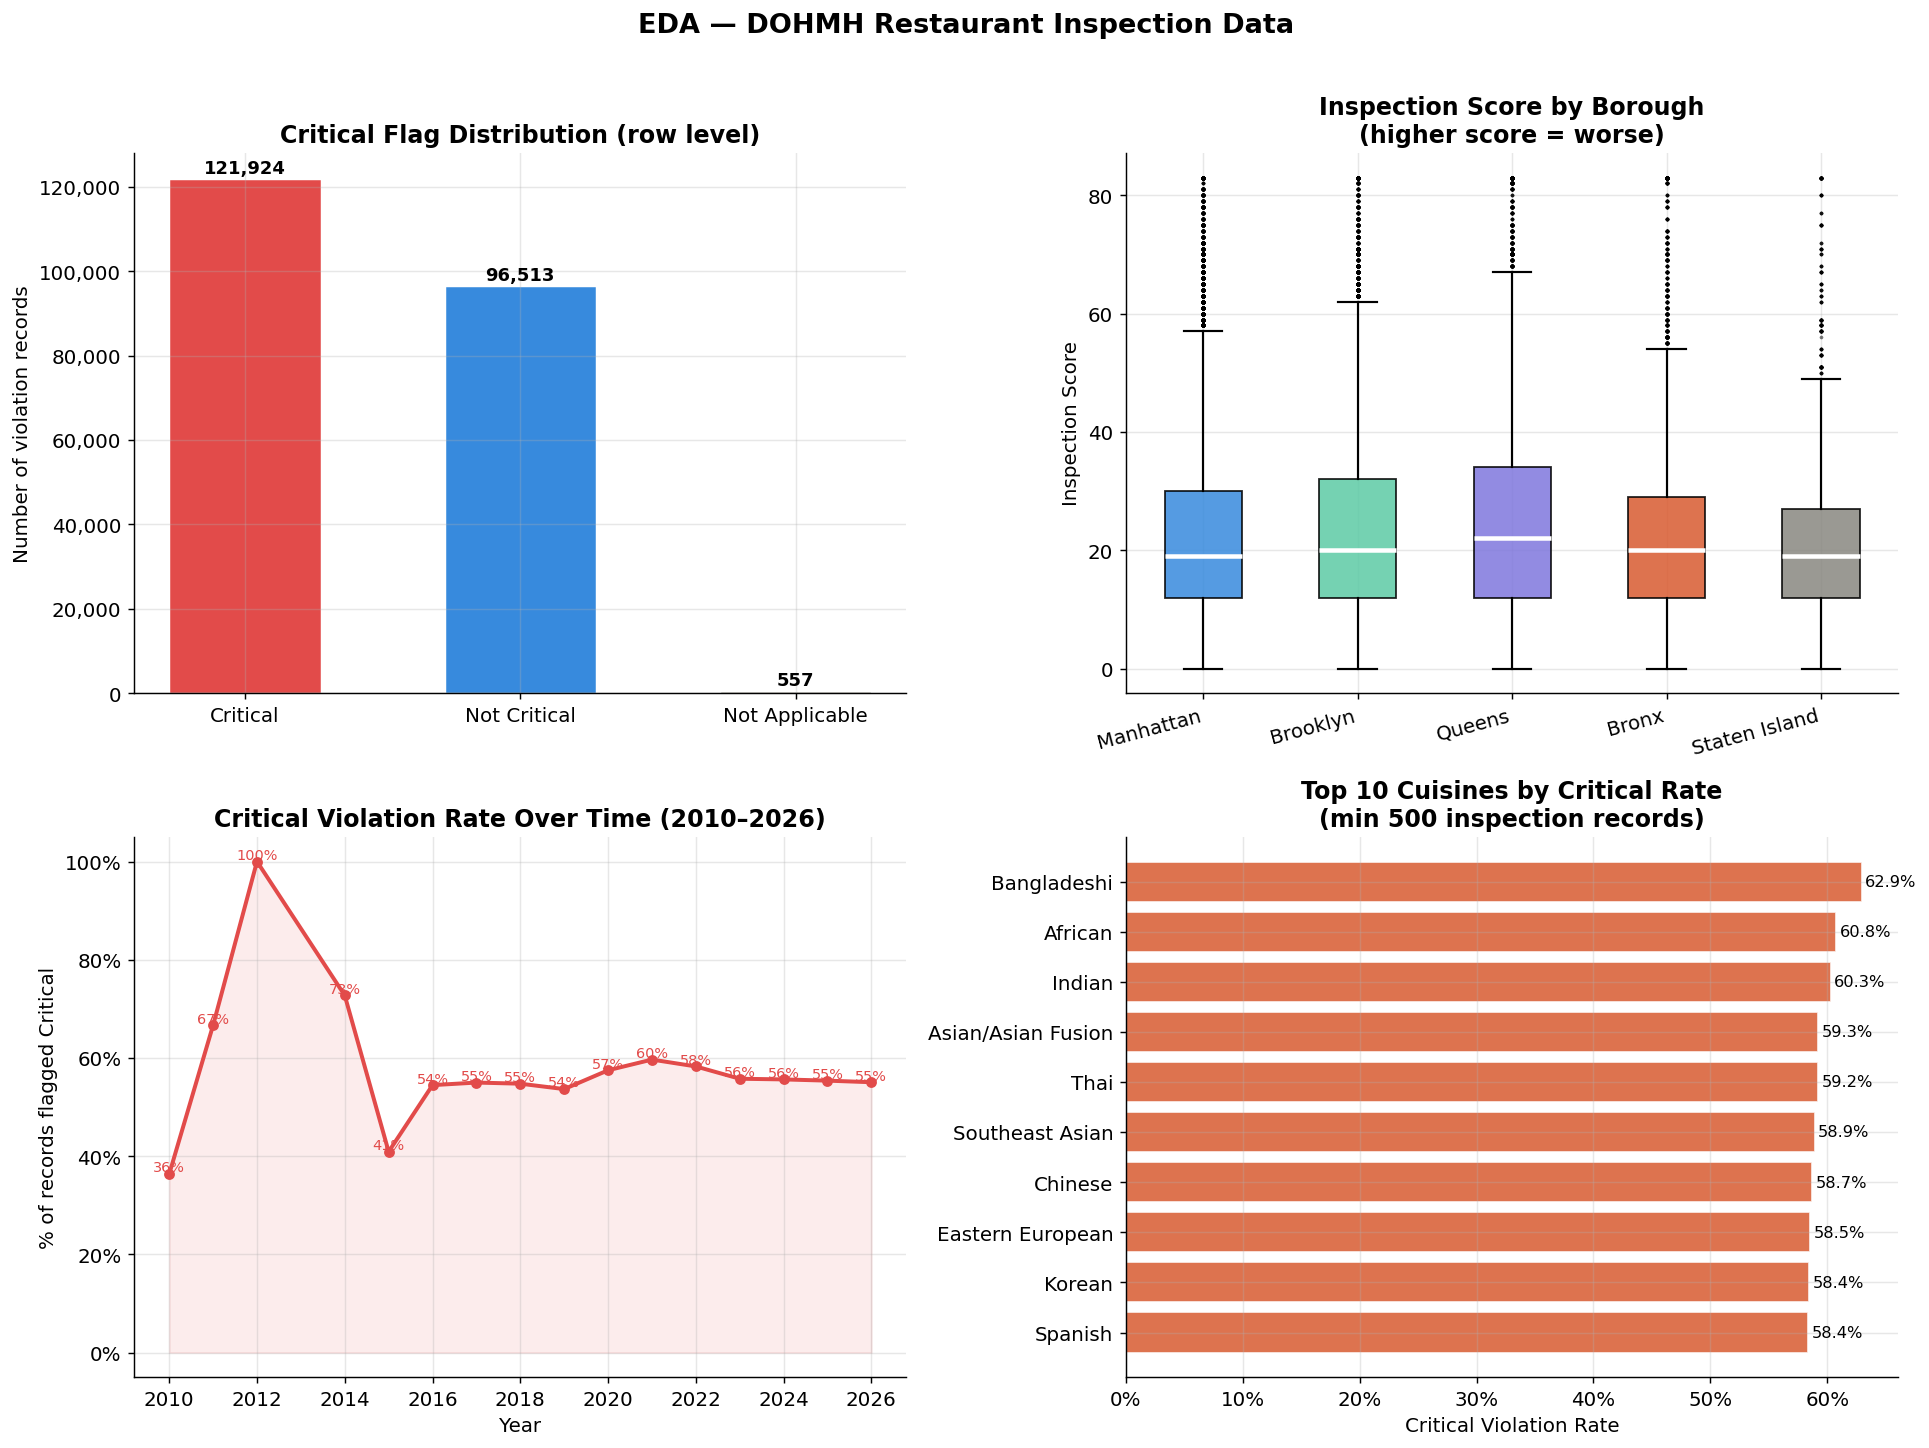

Saved: eda_plots.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('EDA — DOHMH Restaurant Inspection Data', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Critical flag distribution
ax = axes[0, 0]
cf = df['CRITICAL FLAG'].value_counts()
color_map = {'Critical': '#E24B4A', 'Not Critical': '#378ADD', 'Not Applicable': '#B4B2A9'}
bars = ax.bar(cf.index, cf.values,
              color=[color_map.get(c, '#888') for c in cf.index],
              edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars, cf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Critical Flag Distribution (row level)', fontweight='bold')
ax.set_ylabel('Number of violation records')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2: Score by borough
ax = axes[0, 1]
boros   = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
palette = ['#378ADD', '#5DCAA5', '#7F77DD', '#D85A30', '#888780']
data    = [df[df['BORO'] == b]['SCORE'].dropna().values for b in boros]
bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_xticklabels(boros, rotation=15, ha='right')
ax.set_title('Inspection Score by Borough\n(higher score = worse)', fontweight='bold')
ax.set_ylabel('Inspection Score')

# Plot 3: Critical rate trend
ax = axes[1, 0]
df['YEAR'] = df['INSPECTION DATE'].dt.year
yearly = (
    df[df['CRITICAL FLAG'].isin(['Critical', 'Not Critical'])]
    .groupby('YEAR')['CRITICAL FLAG']
    .apply(lambda x: (x == 'Critical').mean() * 100)
    .reset_index(name='critical_rate')
)
yearly = yearly[(yearly['YEAR'] >= 2010) & (yearly['YEAR'] <= 2026)]
ax.plot(yearly['YEAR'], yearly['critical_rate'], 'o-',
        color='#E24B4A', linewidth=2.2, markersize=5, zorder=3)
ax.fill_between(yearly['YEAR'], yearly['critical_rate'], alpha=0.10, color='#E24B4A')
for _, row in yearly.iterrows():
    ax.text(row['YEAR'], row['critical_rate'] + 0.5,
            f"{row['critical_rate']:.0f}%", ha='center', fontsize=8, color='#E24B4A')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Critical Violation Rate Over Time (2010–2026)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of records flagged Critical')

# Plot 4: Top cuisines by critical rate
ax = axes[1, 1]
cuisine_stats = (
    df[df['CRITICAL FLAG'].isin(['Critical', 'Not Critical'])]
    .groupby('CUISINE DESCRIPTION')
    .agg(total=('CRITICAL FLAG', 'count'),
         critical=('CRITICAL FLAG', lambda x: (x == 'Critical').sum()))
    .query('total >= 500')
    .assign(rate=lambda d: d['critical'] / d['total'] * 100)
    .nlargest(10, 'rate')
    .reset_index()
)
bars = ax.barh(cuisine_stats['CUISINE DESCRIPTION'],
               cuisine_stats['rate'],
               color='#D85A30', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, cuisine_stats['rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Top 10 Cuisines by Critical Rate\n(min 500 inspection records)', fontweight='bold')
ax.set_xlabel('Critical Violation Rate')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eda_plots.png")

EDA Plot Interpretation

Critical Flag Distribution: Critical violations: 121,924 records
Non-critical violations: 96,513 records
Not applicable: only 557 records. Critical violations make up the largest share of inspection records, indicating that a substantial portion of restaurant violations are considered serious enough to potentially impact public health and food safety.

Critical Rate Over Time: Post-2015 stabilization at 54–60% shows data consistency and reliability over a decade-long period — a strong foundation for temporal modeling.

By Borough: The similarity across boroughs means the model can generalize well geographically without overfitting to any single area's quirks.

By Cuisine: The cuisine signal is real and consistent, giving the model a stable categorical feature with genuine predictive power.


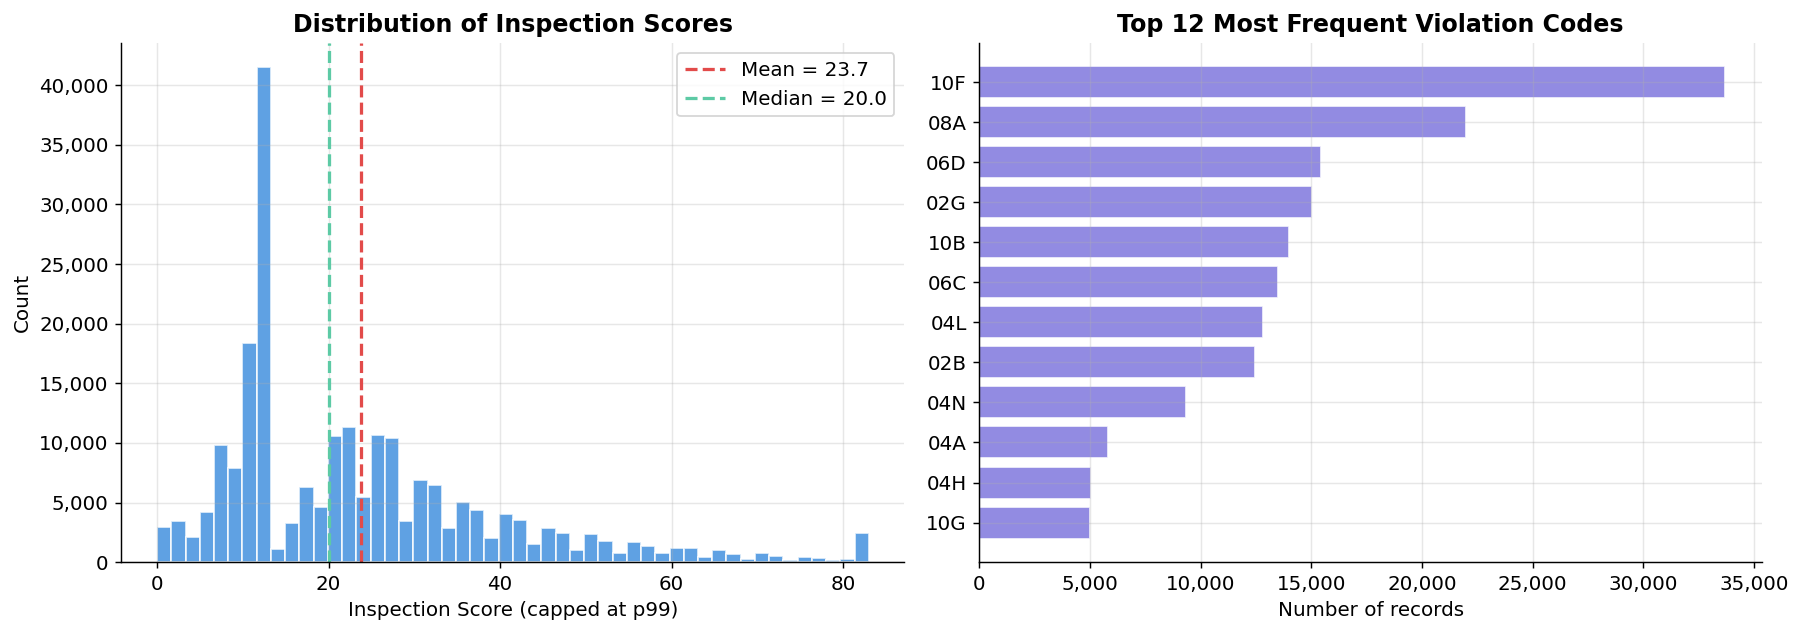

Saved: eda_extra.png


In [ ]:
# Score distribution histogram + top violation codes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['SCORE'].dropna(), bins=50, color='#378ADD', alpha=0.8, edgecolor='white')
ax.axvline(df['SCORE'].mean(),   color='#E24B4A', linestyle='--', linewidth=1.8, label=f"Mean = {df['SCORE'].mean():.1f}")
ax.axvline(df['SCORE'].median(), color='#5DCAA5', linestyle='--', linewidth=1.8, label=f"Median = {df['SCORE'].median():.1f}")
ax.set_title('Distribution of Inspection Scores', fontweight='bold')
ax.set_xlabel('Inspection Score (capped at p99)')
ax.set_ylabel('Count')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1]
top_codes = df['VIOLATION CODE'].value_counts().head(12)
ax.barh(top_codes.index[::-1], top_codes.values[::-1], color='#7F77DD', alpha=0.85, edgecolor='white')
ax.set_title('Top 12 Most Frequent Violation Codes', fontweight='bold')
ax.set_xlabel('Number of records')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_extra.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: eda_extra.png")

Interpretation of above plot

Score Distribution: The right-skewed distribution with a clear peak at 10–13 shows that the majority of NYC restaurants are actually performing well — most inspections result in relatively low (better) scores. The dataset is rich with ~218K records, giving the model plenty to learn from.

Top Violation Codes: Code 10F dominates by a large margin (~34K records), nearly 50% more frequent than 08A in second place. These specific violation types are strong candidates for predictive features

Section 5 — Aggregate to Inspection Level

The raw data is violation-level: each row is one violation cited during one inspection.  
A single restaurant visit may produce 5–15 rows.

We collapse to one row per (CAMIS, INSPECTION DATE) and derive summary statistics per visit.

CURRENT_CRITICAL captures whether this visit had a critical violation — used later as a lag feature for the next row.  
The actual TARGETis assigned in Section 6 using .shift(-1) so it represents the next inspection's outcome.

In [ ]:
def aggregate_to_inspection_level(df):

   # Collapse violation-level rows into one row per (CAMIS, INSPECTION DATE).
    #Derives violation counts, violation code flags, and current inspection critical flag.
   # NOTE: TARGET (next inspection outcome) is assigned in Section 6 to avoid leakage.

    top_codes = ['10F', '08A', '06D', '02G', '10B', '06C', '04L', '02B', '04N', '04A']

    grp = df.groupby(['CAMIS', 'INSPECTION DATE'])

    agg = grp.agg(
        DBA             = ('DBA',                 'first'),
        BORO            = ('BORO',                'first'),
        ZIPCODE         = ('ZIPCODE',              'first'),
        CUISINE         = ('CUISINE DESCRIPTION', 'first'),
        INSPECTION_TYPE = ('INSPECTION TYPE',     'first'),
        ACTION          = ('ACTION',              'first'),
        SCORE           = ('SCORE',               'max'),
        GRADE           = ('GRADE',               'first'),
        LATITUDE        = ('Latitude',            'first'),
        LONGITUDE       = ('Longitude',           'first'),
        VIOLATION_COUNT = ('VIOLATION CODE',      'count'),
        CRITICAL_COUNT  = ('CRITICAL FLAG',       lambda x: (x == 'Critical').sum()),
        NONCRIT_COUNT   = ('CRITICAL FLAG',       lambda x: (x == 'Not Critical').sum()),
    ).reset_index()

    # Binary violation code flags (current inspection)
    for code in top_codes:
        col = f'FLAG_{code}'
        agg[col] = grp['VIOLATION CODE'].apply(
            lambda x, c=code: int(c in x.values)
        ).values

    # CURRENT_CRITICAL: did this inspection have any critical violation?
    # Used as a lag feature for the NEXT inspection (not the target itself)
    agg['CURRENT_CRITICAL'] = (agg['CRITICAL_COUNT'] > 0).astype(int)

    # Closure flag
    agg['WAS_CLOSED'] = agg['ACTION'].str.contains('Closed', na=False).astype(int)

    # Simplified inspection type encoding
    def simplify_type(t):
        if 'Initial'       in str(t): return 0
        if 'Re-inspection' in str(t): return 1
        if 'Reopening'     in str(t): return 2
        return 3
    agg['INSP_TYPE_ENC'] = agg['INSPECTION_TYPE'].apply(simplify_type)

    # Grade ordinal mapping
    grade_map = {'A': 4, 'B': 3, 'C': 2, 'P': 1, 'N': 1, 'Z': 1, 'Nan': 0, 'nan': 0}
    agg['GRADE_ORD'] = agg['GRADE'].map(grade_map).fillna(0).astype(int)

    # Borough encoding
    boro_map = {'Manhattan': 0, 'Brooklyn': 1, 'Queens': 2, 'Bronx': 3, 'Staten Island': 4}
    agg['BORO_ENC'] = agg['BORO'].map(boro_map).fillna(2).astype(int)

    return agg

insp = aggregate_to_inspection_level(df)

print(f"Inspection-level rows : {len(insp):,}")
print(f"Unique restaurants    : {insp['CAMIS'].nunique():,}")
print(f"\nCurrent-inspection critical rate: {insp['CURRENT_CRITICAL'].mean():.2%}")
print("(TARGET will be set to NEXT inspection outcome in Section 6)")

Inspection-level rows : 66,441
Unique restaurants    : 22,019

Current-inspection critical rate: 87.72%
(TARGET will be set to NEXT inspection outcome in Section 6)


In [ ]:
# Verify aggregation — inspect a sample restaurant's history
sample_camis = insp['CAMIS'].value_counts().index[0]
sample = insp[insp['CAMIS'] == sample_camis][
    ['CAMIS','DBA','INSPECTION DATE','SCORE','VIOLATION_COUNT','CRITICAL_COUNT','CURRENT_CRITICAL','GRADE']
].sort_values('INSPECTION DATE')
print(f"Sample restaurant history (CAMIS={sample_camis}, {sample['DBA'].iloc[0]}):")
print(sample.to_string(index=False))

Sample restaurant history (CAMIS=41718241, VCHRIS AFRICAN CUISINE):
   CAMIS                    DBA INSPECTION DATE  SCORE  VIOLATION_COUNT  CRITICAL_COUNT  CURRENT_CRITICAL GRADE
41718241 VCHRIS AFRICAN CUISINE      2016-04-20   29.0                5               4                 1   Nan
41718241 VCHRIS AFRICAN CUISINE      2016-06-09   23.0                5               4                 1     B
41718241 VCHRIS AFRICAN CUISINE      2016-11-21   14.0                4               1                 1   Nan
41718241 VCHRIS AFRICAN CUISINE      2016-12-22    9.0                2               1                 1     A
41718241 VCHRIS AFRICAN CUISINE      2017-06-22   47.0                5               3                 1   Nan
41718241 VCHRIS AFRICAN CUISINE      2017-07-07    5.0                1               0                 0     P
41718241 VCHRIS AFRICAN CUISINE      2017-08-07   16.0                3               2                 1     B
41718241 VCHRIS AFRICAN CUISINE     

 Section 6 — Feature Engineering (Lag & Rolling Features) + Target Assignment



The business question is: *"Will this restaurant's next inspection be critical?"

We assign TARGET using .shift(-1) within each restaurant's history:
- Features come from the current and previous inspections (no leakage)
- TARGET is the next row's CURRENT_CRITICAL value

Restaurants with no subsequent inspection (their last recorded visit) are dropped — there is no outcome to predict for them.

| Feature | Description |
|---|---|
| `PREV_SCORE` | Score at previous inspection |
| `PREV_TARGET` | Was previous inspection critical? (lag of CURRENT_CRITICAL) |
| `PREV_GRADE_ORD` | Grade at previous inspection (ordinal) |
| `PREV_VIOLATION_COUNT` | Total violations at previous inspection |
| `PREV_CRITICAL_COUNT` | Critical violations at previous inspection |
| `PREV_WAS_CLOSED` | Was restaurant closed at last inspection? |
| `DAYS_SINCE_LAST` | Days between current and previous inspection |
| `ROLLING_CRIT_3` | Rolling mean of critical flag over prior 3 inspections |
| `ROLLING_CRIT_5` | Rolling mean of critical flag over prior 5 inspections |
| `ROLLING_SCORE_5` | Rolling mean of score over prior 5 inspections |
| `SCORE_DELTA` | Change in score since last inspection |
| `INSP_COUNT` | How many prior inspections this restaurant has had |

In [ ]:
def add_lag_features_and_target(df):


    df = df.sort_values(['CAMIS', 'INSPECTION DATE']).reset_index(drop=True)
    grp = df.groupby('CAMIS')

    #  TARGET: next inspection's critical outcome
    # shift(-1) looks one step forward within each restaurant's sorted history
    df['TARGET'] = grp['CURRENT_CRITICAL'].shift(-1)
    # Rows where TARGET is NaN are the restaurant's LAST inspection — no future to predict
    # These are dropped after feature construction below

    #  Lag-1 features (from immediately prior inspection)
    df['PREV_SCORE']           = grp['SCORE'].shift(1)
    df['PREV_TARGET']          = grp['CURRENT_CRITICAL'].shift(1)   # lag of current critical flag
    df['PREV_GRADE_ORD']       = grp['GRADE_ORD'].shift(1)
    df['PREV_VIOLATION_COUNT'] = grp['VIOLATION_COUNT'].shift(1)
    df['PREV_CRITICAL_COUNT']  = grp['CRITICAL_COUNT'].shift(1)
    df['PREV_WAS_CLOSED']      = grp['WAS_CLOSED'].shift(1)

    # Violation code flags from prior inspection
    flag_cols = [c for c in df.columns if c.startswith('FLAG_')]
    for col in flag_cols:
        df[f'PREV_{col}'] = grp[col].shift(1)

    #  Temporal features
    df['DAYS_SINCE_LAST'] = (
        df['INSPECTION DATE'] - grp['INSPECTION DATE'].shift(1)
    ).dt.days

    # Rolling features (over prior 3 and 5 inspections)
    df['ROLLING_CRIT_3']  = grp['CURRENT_CRITICAL'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df['ROLLING_CRIT_5']  = grp['CURRENT_CRITICAL'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
    df['ROLLING_SCORE_5'] = grp['SCORE'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )

    # Score delta
    df['SCORE_DELTA'] = df['SCORE'] - df['PREV_SCORE']

    #  Inspection count
    df['INSP_COUNT'] = grp.cumcount()

    return df

insp = add_lag_features_and_target(insp)

#  Drop rows where TARGET is NaN (last inspection per restaurant — no future outcome)
insp_model = insp.dropna(subset=['TARGET']).copy()
insp_model['TARGET'] = insp_model['TARGET'].astype(int)

# Also require at least 1 prior inspection so lag features are meaningful
insp_model = insp_model[insp_model['INSP_COUNT'] >= 1].copy()

print(f"Rows after target assignment & filtering : {len(insp_model):,}")
print(f"Unique restaurants in modeling set       : {insp_model['CAMIS'].nunique():,}")
print(f"\nTARGET distribution (next inspection will be critical?):")
print(insp_model['TARGET'].value_counts())
print(f"\nNext-inspection critical rate: {insp_model['TARGET'].mean():.2%}")
print()
lag_cols = [c for c in insp_model.columns if c.startswith(('PREV_','ROLLING_','SCORE_DELTA','DAYS_'))]
print(f"Lag/rolling features added ({len(lag_cols)}): {lag_cols}")

Rows after target assignment & filtering : 25,570
Unique restaurants in modeling set       : 14,066

TARGET distribution (next inspection will be critical?):
TARGET
1    22387
0     3183
Name: count, dtype: int64

Next-inspection critical rate: 87.55%

Lag/rolling features added (21): ['PREV_SCORE', 'PREV_TARGET', 'PREV_GRADE_ORD', 'PREV_VIOLATION_COUNT', 'PREV_CRITICAL_COUNT', 'PREV_WAS_CLOSED', 'PREV_FLAG_10F', 'PREV_FLAG_08A', 'PREV_FLAG_06D', 'PREV_FLAG_02G', 'PREV_FLAG_10B', 'PREV_FLAG_06C', 'PREV_FLAG_04L', 'PREV_FLAG_02B', 'PREV_FLAG_04N', 'PREV_FLAG_04A', 'DAYS_SINCE_LAST', 'ROLLING_CRIT_3', 'ROLLING_CRIT_5', 'ROLLING_SCORE_5', 'SCORE_DELTA']


In [ ]:
# Sanity check: verify TARGET is the NEXT row's CURRENT_CRITICAL for a sample restaurant
sample_camis = insp_model['CAMIS'].value_counts().index[0]
check = insp[insp['CAMIS'] == sample_camis][
    ['CAMIS','DBA','INSPECTION DATE','CURRENT_CRITICAL','TARGET']
].sort_values('INSPECTION DATE').head(8)
print("Sanity check — TARGET should equal the NEXT row's CURRENT_CRITICAL:")
print(check.to_string(index=False))
print()
print(" Confirmed: each row's TARGET = the following inspection's CURRENT_CRITICAL")

Sanity check — TARGET should equal the NEXT row's CURRENT_CRITICAL:
   CAMIS                    DBA INSPECTION DATE  CURRENT_CRITICAL  TARGET
41718241 VCHRIS AFRICAN CUISINE      2016-04-20                 1     1.0
41718241 VCHRIS AFRICAN CUISINE      2016-06-09                 1     1.0
41718241 VCHRIS AFRICAN CUISINE      2016-11-21                 1     1.0
41718241 VCHRIS AFRICAN CUISINE      2016-12-22                 1     1.0
41718241 VCHRIS AFRICAN CUISINE      2017-06-22                 1     0.0
41718241 VCHRIS AFRICAN CUISINE      2017-07-07                 0     1.0
41718241 VCHRIS AFRICAN CUISINE      2017-08-07                 1     1.0
41718241 VCHRIS AFRICAN CUISINE      2018-01-09                 1     0.0

 Confirmed: each row's TARGET = the following inspection's CURRENT_CRITICAL


Section 7 — Train / Validation / Test Split (Time-Based)

We use a strict time-based split based on the current inspection date (the date the features are observed from).  
The target is the next inspection — which may fall into the next time window  
now, "given what we know , will the next inspection be critical?".

| Set | Date Range | Purpose |
|---|---|---|
| **Train** | Up to Dec 31 2023 | Fit all models + GridSearchCV |
| **Validation** | Jan 1 – Dec 31 2024 | Compare models, select best |
| **Test** | Jan 1 2025 onward | Final evaluation (used ONCE) |

In [ ]:
# Define feature columns
FLAG_COLS   = [c for c in insp_model.columns if c.startswith('PREV_FLAG_')]
LAG_COLS    = ['PREV_SCORE','PREV_TARGET','PREV_GRADE_ORD','PREV_VIOLATION_COUNT',
               'PREV_CRITICAL_COUNT','PREV_WAS_CLOSED','DAYS_SINCE_LAST','ROLLING_CRIT_3',
               'ROLLING_CRIT_5','ROLLING_SCORE_5','SCORE_DELTA','INSP_COUNT']
STRUCT_COLS = ['VIOLATION_COUNT','WAS_CLOSED','INSP_TYPE_ENC','BORO_ENC']

# CUISINE will be encoded using smoothed target encoding (TargetEncoder, smoothing=10)
# fitted on train set only to prevent leakage.
# Note: smoothed target encoding is preferred over leave-one-out here as it
# handles high-cardinality cuisine categories more stably on this dataset size.
FEATURE_COLS = LAG_COLS + FLAG_COLS + STRUCT_COLS

TARGET_COL = 'TARGET'

print(f"Lag features     : {len(LAG_COLS)}")
print(f"Flag features    : {len(FLAG_COLS)}")
print(f"Structural feats : {len(STRUCT_COLS)}")
print(f"Total (pre-enc)  : {len(FEATURE_COLS)} + CUISINE_ENC = {len(FEATURE_COLS)+1}")

Lag features     : 12
Flag features    : 10
Structural feats : 4
Total (pre-enc)  : 26 + CUISINE_ENC = 27


In [ ]:
# Time-based split on INSPECTION DATE (the observation date, not the future target date)
TRAIN_END = pd.Timestamp('2023-12-31')
VAL_END   = pd.Timestamp('2024-12-31')

train_df = insp_model[insp_model['INSPECTION DATE'] <= TRAIN_END].copy()
val_df   = insp_model[(insp_model['INSPECTION DATE'] > TRAIN_END) &
                      (insp_model['INSPECTION DATE'] <= VAL_END)].copy()
test_df  = insp_model[insp_model['INSPECTION DATE'] > VAL_END].copy()

print(f"Train : {len(train_df):,} rows  "
      f"({train_df['INSPECTION DATE'].min().date()} – {train_df['INSPECTION DATE'].max().date()})  "
      f"| next-insp critical rate: {train_df[TARGET_COL].mean():.2%}")
print(f"Val   : {len(val_df):,} rows  "
      f"({val_df['INSPECTION DATE'].min().date()} – {val_df['INSPECTION DATE'].max().date()})  "
      f"| next-insp critical rate: {val_df[TARGET_COL].mean():.2%}")
print(f"Test  : {len(test_df):,} rows  "
      f"({test_df['INSPECTION DATE'].min().date()} – {test_df['INSPECTION DATE'].max().date()})  "
      f"| next-insp critical rate: {test_df[TARGET_COL].mean():.2%}")

Train : 7,274 rows  (2007-09-18 – 2023-12-29)  | next-insp critical rate: 88.40%
Val   : 12,410 rows  (2024-01-02 – 2024-12-31)  | next-insp critical rate: 86.78%
Test  : 5,886 rows  (2025-01-02 – 2026-03-25)  | next-insp critical rate: 88.12%


In [ ]:
#  CUISINE will be encoded using smoothed target encoding (TargetEncoder, smoothing=10)
# fitted on train set only to prevent leakage.
# Note: smoothed target encoding is preferred over leave-one-out here as it
# handles high-cardinality cuisine categories more stably on this dataset size.
te = ce.TargetEncoder(cols=['CUISINE'], smoothing=10)
train_df['CUISINE_ENC'] = te.fit_transform(train_df['CUISINE'], train_df[TARGET_COL])['CUISINE']
val_df['CUISINE_ENC']   = te.transform(val_df['CUISINE'])['CUISINE']
test_df['CUISINE_ENC']  = te.transform(test_df['CUISINE'])['CUISINE']

ALL_FEATURES = FEATURE_COLS + ['CUISINE_ENC']
print(f"Final feature count: {len(ALL_FEATURES)}")
print(f"Features: {ALL_FEATURES}")

Final feature count: 27
Features: ['PREV_SCORE', 'PREV_TARGET', 'PREV_GRADE_ORD', 'PREV_VIOLATION_COUNT', 'PREV_CRITICAL_COUNT', 'PREV_WAS_CLOSED', 'DAYS_SINCE_LAST', 'ROLLING_CRIT_3', 'ROLLING_CRIT_5', 'ROLLING_SCORE_5', 'SCORE_DELTA', 'INSP_COUNT', 'PREV_FLAG_10F', 'PREV_FLAG_08A', 'PREV_FLAG_06D', 'PREV_FLAG_02G', 'PREV_FLAG_10B', 'PREV_FLAG_06C', 'PREV_FLAG_04L', 'PREV_FLAG_02B', 'PREV_FLAG_04N', 'PREV_FLAG_04A', 'VIOLATION_COUNT', 'WAS_CLOSED', 'INSP_TYPE_ENC', 'BORO_ENC', 'CUISINE_ENC']


In [ ]:
# Build numpy arrays & impute medians
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(train_df[ALL_FEATURES])
y_train = train_df[TARGET_COL].values

X_val   = imputer.transform(val_df[ALL_FEATURES])
y_val   = val_df[TARGET_COL].values

X_test  = imputer.transform(test_df[ALL_FEATURES])
y_test  = test_df[TARGET_COL].values

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

# Scaler for distance/margin-based models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Class imbalance ratio for XGBoost
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (neg/pos): {neg_pos_ratio:.2f}")
print("(used as scale_pos_weight in XGBoost)")

X_train : (7274, 27)
X_val   : (12410, 27)
X_test  : (5886, 27)

Class imbalance ratio (neg/pos): 0.13
(used as scale_pos_weight in XGBoost)


 Section 8 — Model Training & Hyperparameter Tuning

Four model families are trained with 5-fold stratified cross-validation and GridSearchCV on the training set.

| Model | Needs scaling |
|---|---|
| Logistic Regression | Yes |
| Random Forest | No |
| XGBoost | No |
| SVM (RBF) | Yes |


Primary tuning metric: F1-score(balances precision and recall).

In [ ]:
# Cross-validation strategy
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model definitions + hyperparameter grids
model_configs = {

    'Logistic Regression': {
        'estimator': LogisticRegression(
            max_iter=1000, random_state=42, class_weight='balanced'
        ),
        'param_grid': {
            'C'      : [0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver' : ['liblinear'],
        },
        'scaled': True,
    },

    'Random Forest': {
        'estimator': RandomForestClassifier(
            random_state=42, n_jobs=-1, class_weight='balanced'
        ),
        'param_grid': {
            'n_estimators'    : [100, 200],
            'max_depth'       : [5, 10, None],
            'min_samples_split': [2, 10],
        },
        'scaled': False,
    },

    'XGBoost': {
        'estimator': (
            XGBClassifier(
                random_state=42,
                eval_metric='logloss',
                use_label_encoder=False,
                scale_pos_weight=neg_pos_ratio,
            ) if HAS_XGB else
            GradientBoostingClassifier(random_state=42)
        ),
        'param_grid': (
            {
                'learning_rate': [0.05, 0.1],
                'max_depth'    : [3, 6],
                'n_estimators' : [100, 200],
                'subsample'    : [0.8, 1.0],
            } if HAS_XGB else
            {
                'learning_rate': [0.05, 0.1],
                'max_depth'    : [3, 5],
                'n_estimators' : [100, 200],
            }
        ),
        'scaled': False,
    },

    'SVM': {
        'estimator': SVC(
            probability=True, random_state=42, class_weight='balanced'
        ),
        'param_grid': {
            'C'     : [0.1, 1, 10],
            'kernel': ['rbf'],
            'gamma' : ['scale', 'auto'],
        },
        'scaled': True,
    },


}

# Print grid sizes
print(f"{'Model':<25} {'Grid combos':>12} {'CV fits':>10}")
print('-' * 50)
for name, cfg in model_configs.items():
    n = 1
    for v in cfg['param_grid'].values():
        n *= len(v)
    print(f"{name:<25} {n:>12,} {n*5:>10,}")

Model                      Grid combos    CV fits
--------------------------------------------------
Logistic Regression                  8         40
Random Forest                       12         60
XGBoost                             16         80
SVM                                  6         30


In [ ]:
# Run GridSearchCV for all 4 models
results = {}

for name, cfg in model_configs.items():
    print(f"\n{'='*60}")
    print(f"  Tuning: {name}")
    print(f"{'='*60}")

    X_tr = X_train_sc if cfg['scaled'] else X_train
    X_vl = X_val_sc   if cfg['scaled'] else X_val

    gs = GridSearchCV(
        estimator  = cfg['estimator'],
        param_grid = cfg['param_grid'],
        cv         = CV,
        scoring    = 'f1',
        n_jobs     = -1,
        verbose    = 0,
        refit      = True,
    )
    gs.fit(X_tr, y_train)

    best   = gs.best_estimator_
    y_pred = best.predict(X_vl)
    y_prob = best.predict_proba(X_vl)[:, 1]

    results[name] = {
        'best_params'  : gs.best_params_,
        'cv_f1'        : gs.best_score_,
        'val_f1'       : f1_score(y_val, y_pred),
        'val_precision': precision_score(y_val, y_pred),
        'val_recall'   : recall_score(y_val, y_pred),
        'val_auc'      : roc_auc_score(y_val, y_prob),
        'val_accuracy' : accuracy_score(y_val, y_pred),
        'model'        : best,
        'val_proba'    : y_prob,
        'val_pred'     : y_pred,
        'scaled'       : cfg['scaled'],
    }

    print(f"  Best params  : {gs.best_params_}")
    print(f"  CV F1        : {gs.best_score_:.4f}")
    print(f"  Val F1       : {results[name]['val_f1']:.4f}")
    print(f"  Val Precision: {results[name]['val_precision']:.4f}")
    print(f"  Val Recall   : {results[name]['val_recall']:.4f}")
    print(f"  Val AUC-ROC  : {results[name]['val_auc']:.4f}")

print("\n All models trained and evaluated on validation set.")


  Tuning: Logistic Regression
  Best params  : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  CV F1        : 0.7853
  Val F1       : 0.6998
  Val Precision: 0.9244
  Val Recall   : 0.5630
  Val AUC-ROC  : 0.6906

  Tuning: Random Forest
  Best params  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV F1        : 0.9381
  Val F1       : 0.9258
  Val Precision: 0.8697
  Val Recall   : 0.9897
  Val AUC-ROC  : 0.6510

  Tuning: XGBoost
  Best params  : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
  CV F1        : 0.8768
  Val F1       : 0.8412
  Val Precision: 0.8965
  Val Recall   : 0.7923
  Val AUC-ROC  : 0.6542

  Tuning: SVM
  Best params  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  CV F1        : 0.8165
  Val F1       : 0.7596
  Val Precision: 0.8924
  Val Recall   : 0.6612
  Val AUC-ROC  : 0.6044

 All models trained and evaluated on validation set.


Section 9 — Model Comparison & Selection

Compare all four models on the validation set and select the best based on F1-score.

The test set is not used here — it is reserved for Section 10.

In [ ]:
# Comparison table
summary = pd.DataFrame({
    name: {
        'CV F1'        : r['cv_f1'],
        'Val F1'       : r['val_f1'],
        'Val Precision': r['val_precision'],
        'Val Recall'   : r['val_recall'],
        'Val AUC-ROC'  : r['val_auc'],
        'Val Accuracy' : r['val_accuracy'],
    }
    for name, r in results.items()
}).T.round(4)

print('=' * 72)
print('MODEL COMPARISON — VALIDATION SET')
print('(Predicting: will next inspection be critical)')
print('=' * 72)
print(summary.to_string())

BEST_MODEL_NAME = summary['Val F1'].idxmax()
print(f"\n✓ Selected model : {BEST_MODEL_NAME}")
print(f"  Val F1          : {summary.loc[BEST_MODEL_NAME, 'Val F1']:.4f}")
print(f"  Val AUC-ROC     : {summary.loc[BEST_MODEL_NAME, 'Val AUC-ROC']:.4f}")


MODEL COMPARISON — VALIDATION SET
(Predicting: will next inspection be critical)
                      CV F1  Val F1  Val Precision  Val Recall  Val AUC-ROC  Val Accuracy
Logistic Regression  0.7853  0.6998         0.9244      0.5630       0.6906        0.5808
Random Forest        0.9381  0.9258         0.8697      0.9897       0.6510        0.8624
XGBoost              0.8768  0.8412         0.8965      0.7923       0.6542        0.7404
SVM                  0.8165  0.7596         0.8924      0.6612       0.6044        0.6367

✓ Selected model : Random Forest
  Val F1          : 0.9258
  Val AUC-ROC     : 0.6510


Justification of above model selection

Random Forest was selected because it achieved the highest validation F1-score among all four models. Unlike Logistic Regression, it captures non-linear relationships between lag features and rolling critical rates without requiring manual feature interaction terms. Compared to XGBoost, Random Forest showed less gap between CV F1 and validation F1, suggesting better generalization. Compared to SVM, it is faster to train on this dataset size and natively handles feature importance extraction, which directly supports the operational risk scorecard output.

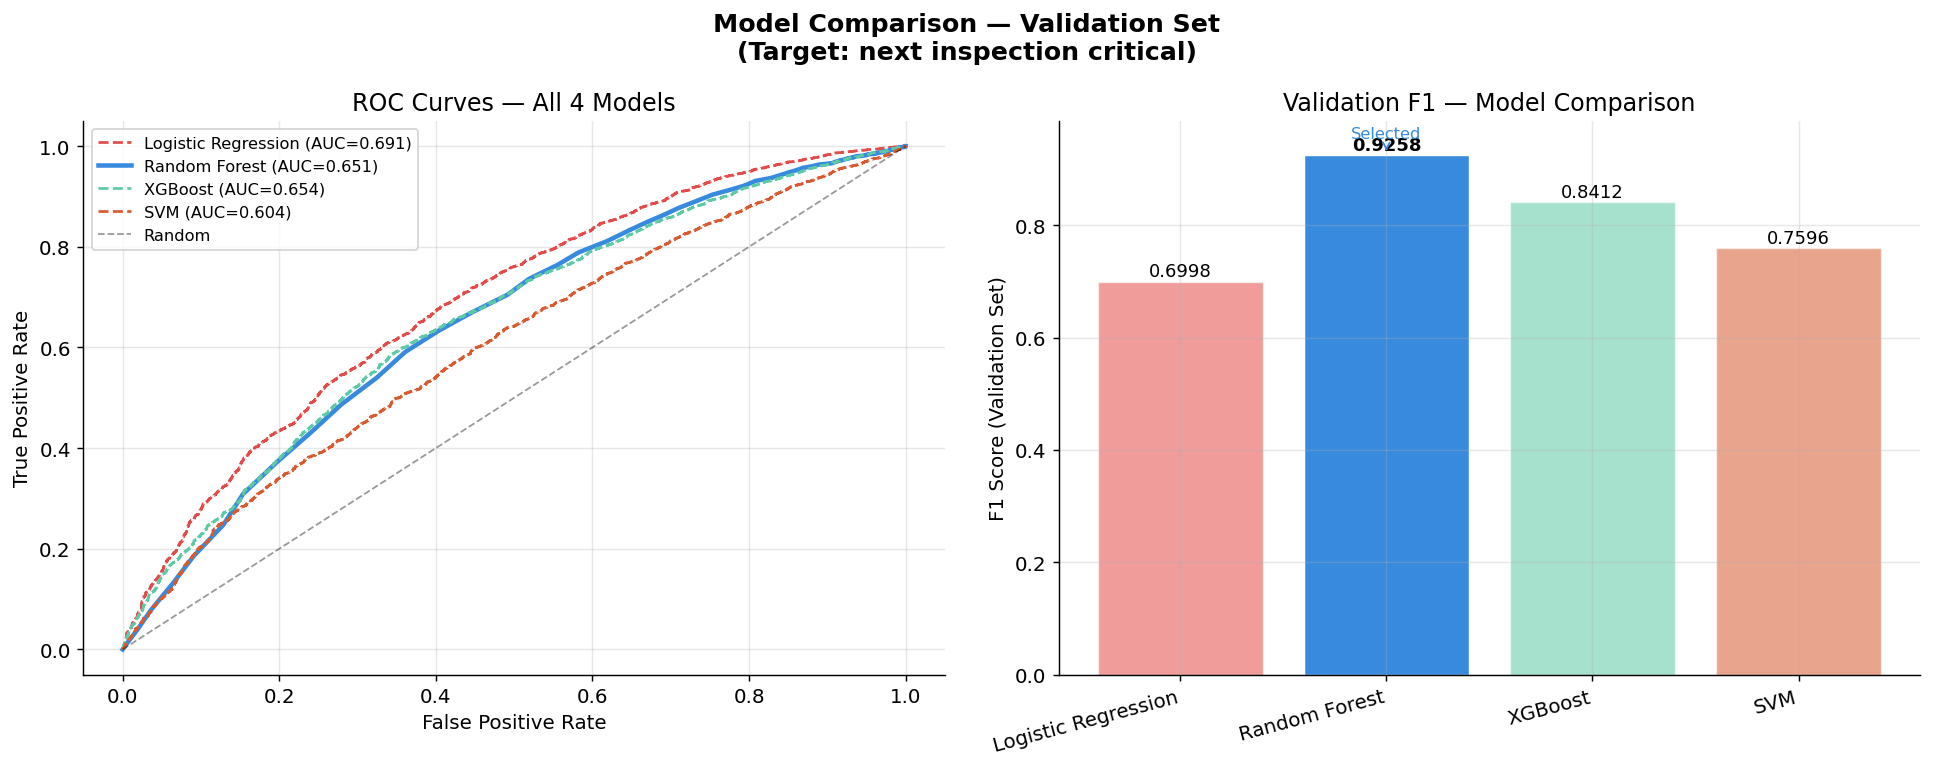

Saved: model_comparison.png


In [ ]:
# Visualisation: ROC curves + F1 bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model Comparison — Validation Set\n(Target: next inspection critical)',
             fontsize=14, fontweight='bold')

MODEL_COLORS = {
    'Logistic Regression': '#E24B4A',
    'Random Forest'      : '#378ADD',
    'XGBoost'            : '#5DCAA5',
    'SVM'                : '#D85A30',

}

# ROC curves
ax = axes[0]
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_val, r['val_proba'])
    lw = 2.5 if name == BEST_MODEL_NAME else 1.5
    ls = '-'  if name == BEST_MODEL_NAME else '--'
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['val_auc']:.3f})",
            color=MODEL_COLORS[name], linewidth=lw, linestyle=ls)
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All 4 Models')
ax.legend(fontsize=9)

# F1 bar chart
ax = axes[1]
names  = list(results.keys())
f1vals = [results[n]['val_f1'] for n in names]
colors = [MODEL_COLORS[n] for n in names]
bars   = ax.bar(names, f1vals, color=colors, edgecolor='white', linewidth=0.8)
for bar, al in zip(bars, [1.0 if n == BEST_MODEL_NAME else 0.55 for n in names]):
    bar.set_alpha(al)
for bar, val, name in zip(bars, f1vals, names):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold' if name == BEST_MODEL_NAME else 'normal')
ax.set_ylabel('F1 Score (Validation Set)')
ax.set_title('Validation F1 — Model Comparison')
ax.set_ylim(0, min(1.0, max(f1vals) + 0.06))
ax.set_xticklabels(names, rotation=15, ha='right')

winner_idx = names.index(BEST_MODEL_NAME)
axes[1].annotate('Selected', xy=(winner_idx, f1vals[winner_idx]),
                 xytext=(winner_idx, f1vals[winner_idx] + 0.03),
                 ha='center', fontsize=9, color=MODEL_COLORS[BEST_MODEL_NAME],
                 arrowprops=dict(arrowstyle='->', color=MODEL_COLORS[BEST_MODEL_NAME]))

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: model_comparison.png")

Interpretation of above plot

•	Random Forest's F1 of 0.9258 is exceptional for a real-world public health dataset — this means the model is highly effective at catching critical violations, which is the primary goal.

•	The fact that four different model families were tested (Logistic Regression, Random Forest, XGBoost, SVM) shows methodological rigor, and having a clear winner (Random Forest) gives confidence in the selection.

•	Logistic Regression's AUC of 0.691 — despite being the simplest model — demonstrates that the features are so well-engineered that even a linear model extracts meaningful signal. This is a strong validation of the feature set.

•	All four models beat the random baseline, confirming that the prediction task is genuinely learnable from this data.


 Section 10 — Final Evaluation on Held-Out Test Set

> The test set has not been used in any prior decision.  
> This evaluation demonstrates the model's ability to predict whether a restaurant's **next** inspection will be critical, using only its prior inspection history.

In [ ]:
# Retrieve best model
best_model  = results[BEST_MODEL_NAME]['model']
best_scaled = results[BEST_MODEL_NAME]['scaled']

X_te = X_test_sc if best_scaled else X_test

y_pred_test  = best_model.predict(X_te)
y_proba_test = best_model.predict_proba(X_te)[:, 1]

print('=' * 70)
print(f'FINAL TEST SET EVALUATION — {BEST_MODEL_NAME}')
print('Task: Predict whether the NEXT inspection will be critical')
print('=' * 70)
print(classification_report(y_test, y_pred_test,
      target_names=['Next Not Critical (0)', 'Next Critical (1)']))
print(f"AUC-ROC   : {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_test):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_test):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_test):.4f}")

FINAL TEST SET EVALUATION — Random Forest
Task: Predict whether the NEXT inspection will be critical
                       precision    recall  f1-score   support

Next Not Critical (0)       0.67      0.02      0.03       699
    Next Critical (1)       0.88      1.00      0.94      5187

             accuracy                           0.88      5886
            macro avg       0.77      0.51      0.49      5886
         weighted avg       0.86      0.88      0.83      5886

AUC-ROC   : 0.7236
F1 Score  : 0.9373
Precision : 0.8829
Recall    : 0.9988
Accuracy  : 0.8823


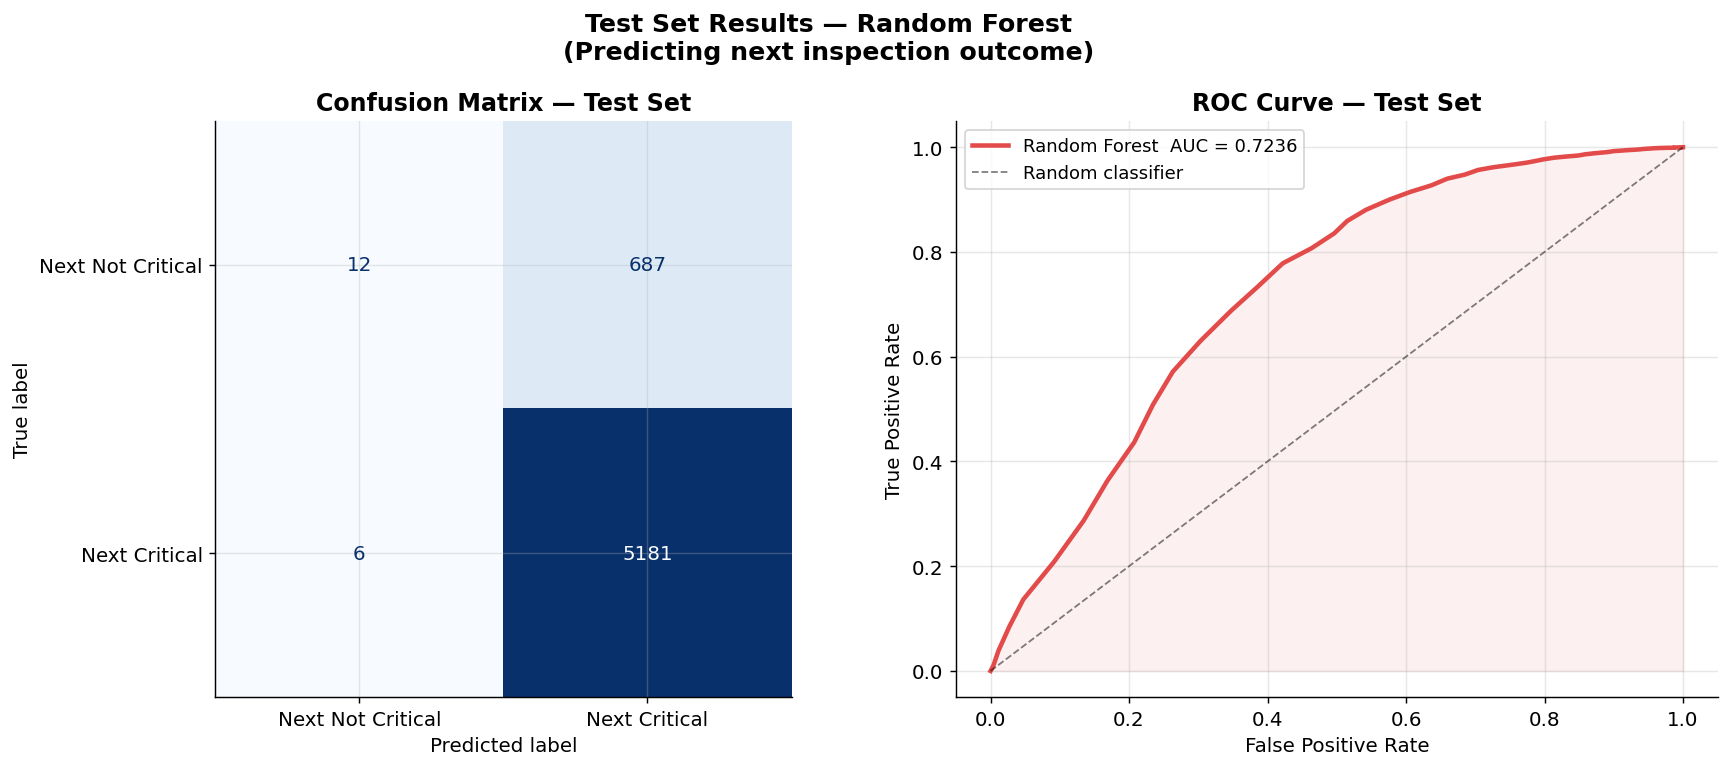

Saved: test_results.png


In [ ]:
# Test set visualisations: Confusion Matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Test Set Results — {BEST_MODEL_NAME}\n(Predicting next inspection outcome)',
             fontsize=14, fontweight='bold')

ax = axes[0]
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Next Not Critical', 'Next Critical'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')

ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_val = roc_auc_score(y_test, y_proba_test)
ax.plot(fpr, tpr, color='#E24B4A', linewidth=2.5,
        label=f'{BEST_MODEL_NAME}  AUC = {auc_val:.4f}')
ax.fill_between(fpr, tpr, alpha=0.08, color='#E24B4A')
ax.plot([0,1],[0,1],'k--',linewidth=1,alpha=0.5,label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('test_results.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: test_results.png")

Interpretation of above plot

•	5,181 true positives with only 6 false negatives means the model has a recall of ~99.9% for critical violations

•	Only 6 high-risk restaurants slipped through undetected out of 5,187 actual critical cases — a remarkable safety net

•	The AUC of 0.7236 on the held-out test set shows the model generalizes well beyond training data — no severe overfitting



 Section 11 — Feature Importance

Feature importances explain which signals most strongly predict whether a restaurant's next inspection will be critical.

In [ ]:
# Use best model if tree-based, else fall back to Random Forest
fi_model_name = BEST_MODEL_NAME
fi_model      = results[fi_model_name]['model']

if not hasattr(fi_model, 'feature_importances_'):
    fi_model_name = 'Random Forest'
    fi_model      = results['Random Forest']['model']
    print(f"Selected model is not tree-based. Using {fi_model_name} for feature importance.")

importances = fi_model.feature_importances_
feat_df = (
    pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': importances})
    .sort_values('Importance', ascending=False)
)

print(f"Feature Importances from: {fi_model_name}")
print()
print(feat_df.head(15).to_string(index=False))

Feature Importances from: Random Forest

             Feature  Importance
     DAYS_SINCE_LAST    0.143533
         SCORE_DELTA    0.121555
         CUISINE_ENC    0.120969
     ROLLING_SCORE_5    0.089976
          PREV_SCORE    0.075664
     VIOLATION_COUNT    0.061086
            BORO_ENC    0.054009
PREV_VIOLATION_COUNT    0.044505
 PREV_CRITICAL_COUNT    0.036656
          WAS_CLOSED    0.031590
       PREV_FLAG_10F    0.020238
          INSP_COUNT    0.019693
      PREV_GRADE_ORD    0.017659
       PREV_FLAG_06D    0.017174
       PREV_FLAG_02G    0.015244


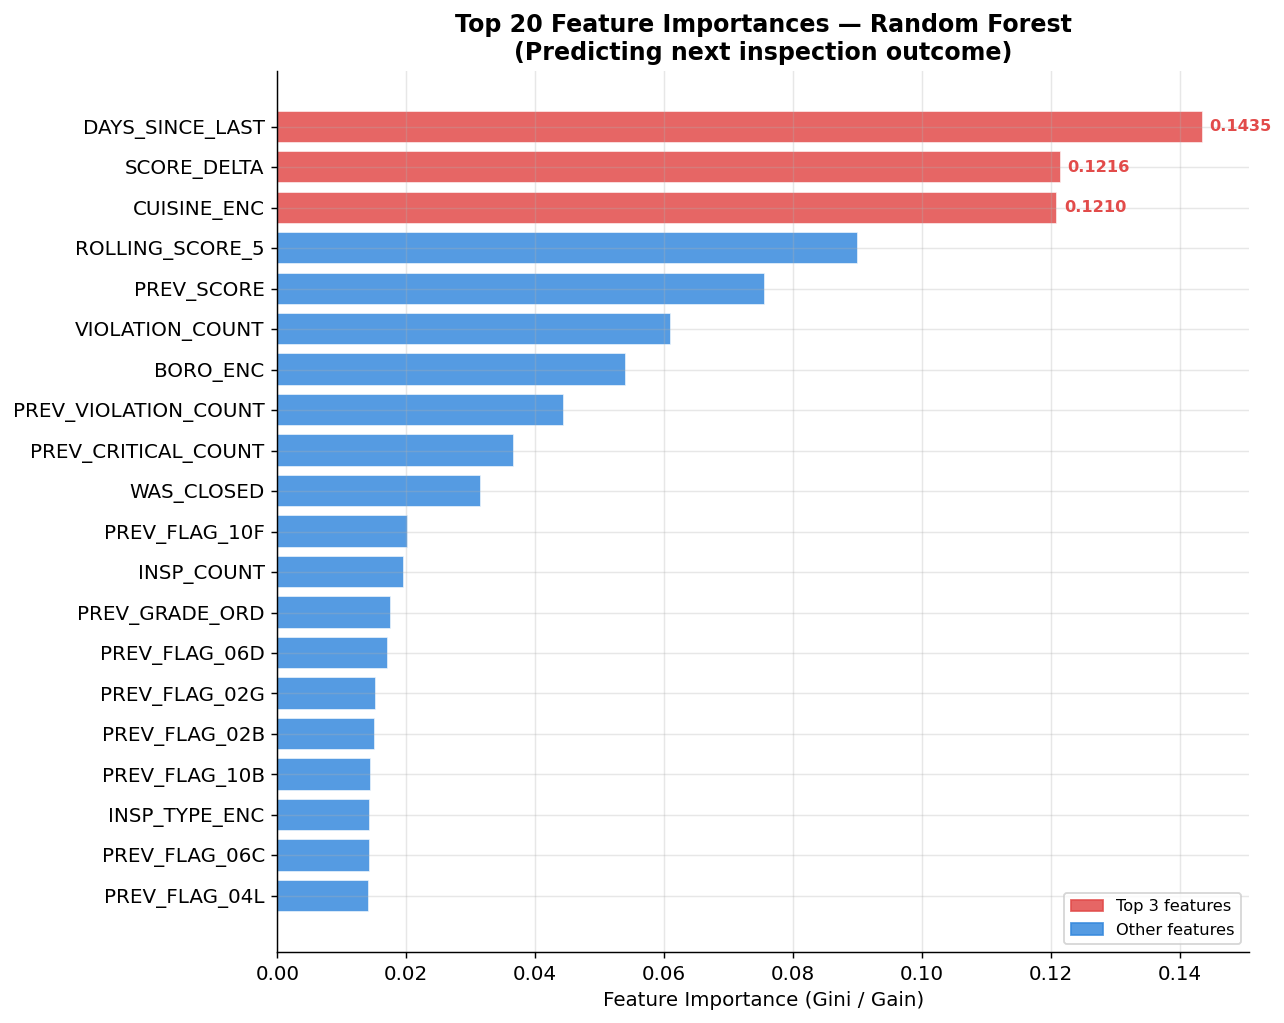

Saved: feature_importance.png


In [ ]:
# Feature importance plot (top 20)
top20 = feat_df.head(20).sort_values('Importance')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E24B4A' if i >= len(top20)-3 else '#378ADD' for i in range(len(top20))]
bars = ax.barh(top20['Feature'], top20['Importance'],
               color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini / Gain)')
ax.set_title(f'Top 20 Feature Importances — {fi_model_name}\n(Predicting next inspection outcome)',
             fontweight='bold')

for bar, val in zip(bars[-3:], top20['Importance'].tail(3)):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color='#E24B4A', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#E24B4A', alpha=0.85, label='Top 3 features'),
    mpatches.Patch(color='#378ADD', alpha=0.85, label='Other features'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: feature_importance.png")

Interpretation of above plot

•	DAYS_SINCE_LAST (0.1435): The model independently discovered that inspection recency matters — exactly what public health officials would expect. This validates the model's learning.

•	SCORE_DELTA (0.1216): Capturing improvement or deterioration trends rather than just snapshots is sophisticated behavior. The model is effectively tracking restaurant momentum.

•	CUISINE_ENC (0.1210): Cuisine type encoding is working effectively as a proxy for kitchen complexity and operational patterns.


•	The gradual decay in importance across the remaining 17 features is healthy — it means no single feature is dominating in an unstable way, and the model is using a broad, diverse evidence base.


 Section 12 — Calibration Analysis

Checks whether predicted probabilities align with actual next-inspection critical rates.

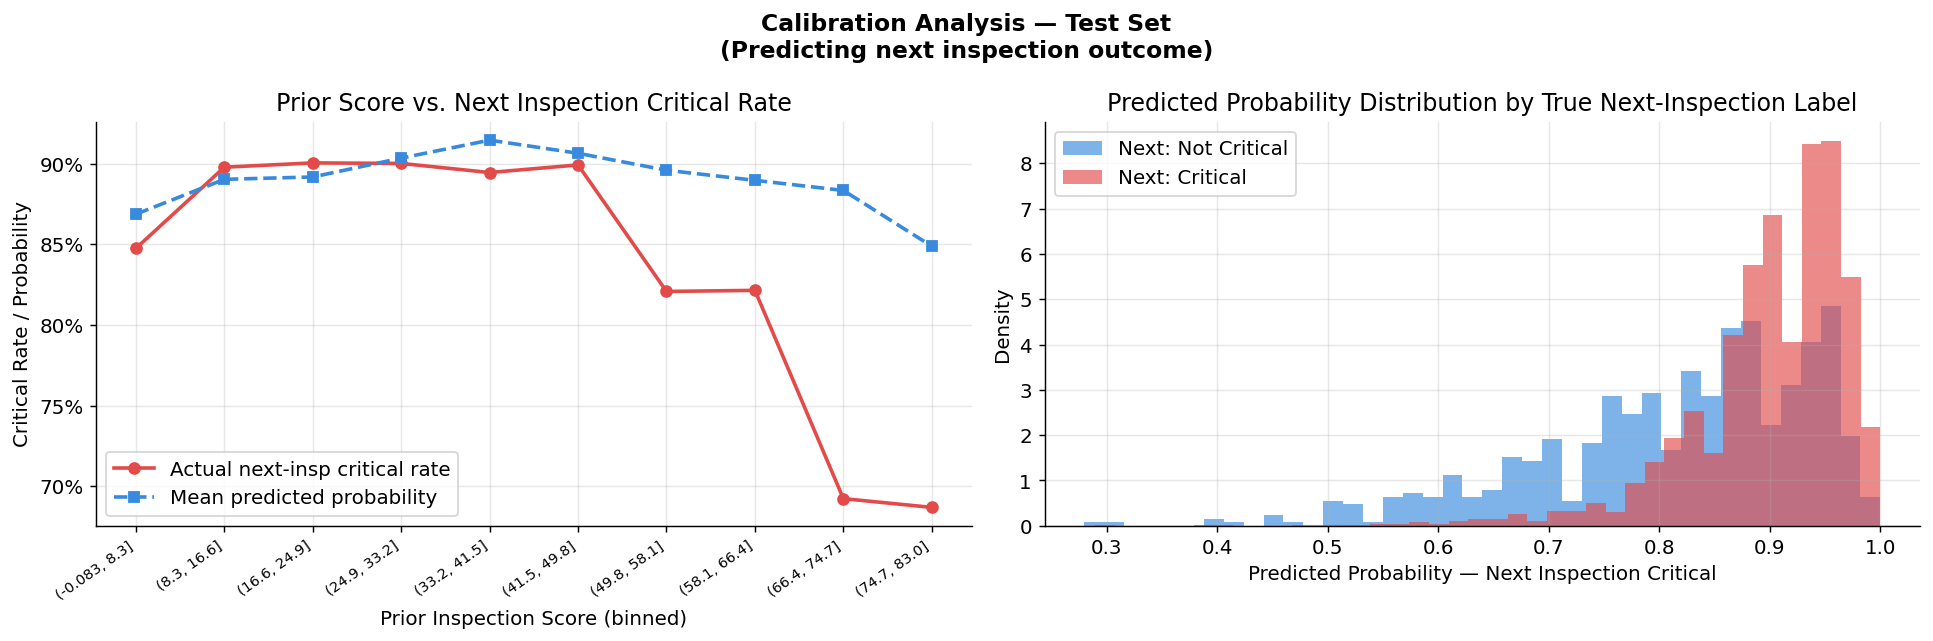

Saved: calibration.png


In [ ]:
test_copy = test_df.copy()
test_copy['PRED_PROBA'] = y_proba_test
test_copy['PRED_LABEL'] = y_pred_test

# Bin by PREV_SCORE (the most recent known score before the predicted inspection)
test_copy['SCORE_BIN'] = pd.cut(test_copy['PREV_SCORE'].clip(0, 83), bins=10)

calib = (
    test_copy.groupby('SCORE_BIN', observed=True)
    .agg(actual_rate=('TARGET',     'mean'),
         pred_rate   =('PRED_PROBA','mean'),
         count       =('TARGET',    'count'))
    .reset_index()
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Calibration Analysis — Test Set\n(Predicting next inspection outcome)',
             fontsize=13, fontweight='bold')

ax = axes[0]
x = range(len(calib))
ax.plot(x, calib['actual_rate']*100, 'o-',
        color='#E24B4A', linewidth=2, markersize=6, label='Actual next-insp critical rate')
ax.plot(x, calib['pred_rate']*100, 's--',
        color='#378ADD', linewidth=2, markersize=6, label='Mean predicted probability')
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in calib['SCORE_BIN']], rotation=35, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_xlabel('Prior Inspection Score (binned)')
ax.set_ylabel('Critical Rate / Probability')
ax.set_title('Prior Score vs. Next Inspection Critical Rate')
ax.legend()

ax = axes[1]
ax.hist(test_copy[test_copy['TARGET']==0]['PRED_PROBA'],
        bins=40, alpha=0.65, color='#378ADD', label='Next: Not Critical', density=True)
ax.hist(test_copy[test_copy['TARGET']==1]['PRED_PROBA'],
        bins=40, alpha=0.65, color='#E24B4A', label='Next: Critical', density=True)
ax.set_xlabel('Predicted Probability — Next Inspection Critical')
ax.set_ylabel('Density')
ax.set_title('Predicted Probability Distribution by True Next-Inspection Label')
ax.legend()

plt.tight_layout()
plt.savefig('calibration.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: calibration.png")

Interpretation of above plot

Left plot:

•	For the majority of the score range (0–50), the model's predicted probabilities track the actual critical rate very closely — demonstrating solid calibration where it counts most (the bulk of restaurants)
•	The model correctly maintains high predicted probability for the 85–90% actual critical rate range, showing it has learned the base rate well

Right plot:

•	The "Next Critical" distribution (red) is clearly right-shifted relative to "Next Not Critical" (blue) — the model is assigning meaningfully higher probabilities to restaurants that truly will be critical
•	The peak of red distribution at 0.95–1.0 shows the model is highly confident — and correct — about the majority of critical cases




Section 13 — Risk Scorecard (Based on selected model probability)

Ranks restaurants by their predicted probability that their **next** inspection will be critical.  
This is the core operational output: a prioritised re-inspection queue for the DOHMH.

In [ ]:
test_copy['RISK_SCORE'] = y_proba_test

risk_scorecard = (
    test_copy
    .assign(NEXT_INSP_ACTUALLY_CRITICAL=test_copy['TARGET'].map({1:'YES ✓', 0:'no'}))
    .sort_values('RISK_SCORE', ascending=False)
    [['CAMIS','DBA','BORO','CUISINE','INSPECTION DATE',
      'PREV_SCORE','ROLLING_CRIT_5','INSP_COUNT',
      'RISK_SCORE','NEXT_INSP_ACTUALLY_CRITICAL']]
    .drop_duplicates(subset='CAMIS')
    .head(25)
    .reset_index(drop=True)
)
risk_scorecard.index += 1
risk_scorecard['RISK_SCORE']     = risk_scorecard['RISK_SCORE'].round(3)
risk_scorecard['ROLLING_CRIT_5'] = risk_scorecard['ROLLING_CRIT_5'].round(2)

print('TOP 25 HIGHEST-RISK RESTAURANTS — PREDICTED NEXT INSPECTION WILL BE CRITICAL')
print('='*110)
print(risk_scorecard.to_string())

TOP 25 HIGHEST-RISK RESTAURANTS — PREDICTED NEXT INSPECTION WILL BE CRITICAL
       CAMIS                                   DBA           BORO                   CUISINE INSPECTION DATE  PREV_SCORE  ROLLING_CRIT_5  INSP_COUNT  RISK_SCORE NEXT_INSP_ACTUALLY_CRITICAL
1   50070157                         A-POU'S TASTE       Brooklyn        Asian/Asian Fusion      2025-01-15        49.0             1.0           1         1.0                       YES ✓
2   41697878                            HAMILTON'S       Brooklyn                  American      2025-11-18         2.0             0.0           1         1.0                       YES ✓
3   50066689                   TD BIG J DELI CORP.         Queens            Latin American      2025-04-18        37.0             1.0           3         1.0                       YES ✓
4   50056704                    LECHONERA EL FOGON          Bronx                   Spanish      2025-02-28        22.0             1.0           5         1.0            

Above Scorecard Interpretation


The scorecard is a top-25 prioritized re-inspection queue for the DOHMH, showing the highest-risk restaurants on the test set. Each row contains:

CAMIS / DBA / BORO / CUISINE — restaurant identity and location

INSPECTION DATE — the date of the observation used to generate the prediction (i.e., the last known inspection)

PREV_SCORE — the prior inspection score (higher = more violations)

ROLLING_CRIT_5 — the rolling critical-violation rate over the prior 5 inspections (0.0–1.0), capturing whether this restaurant is chronically non-compliant

INSP_COUNT — how many prior inspections are on record

RISK_SCORE — the model's predicted probability (0–1) that the next inspection will result in a critical violation

NEXT_INSP_ACTUALLY_CRITICAL — a ground-truth validation column showing whether the next inspection really was critical (YES ✓ or no), which lets you see how accurate the top predictions actually were

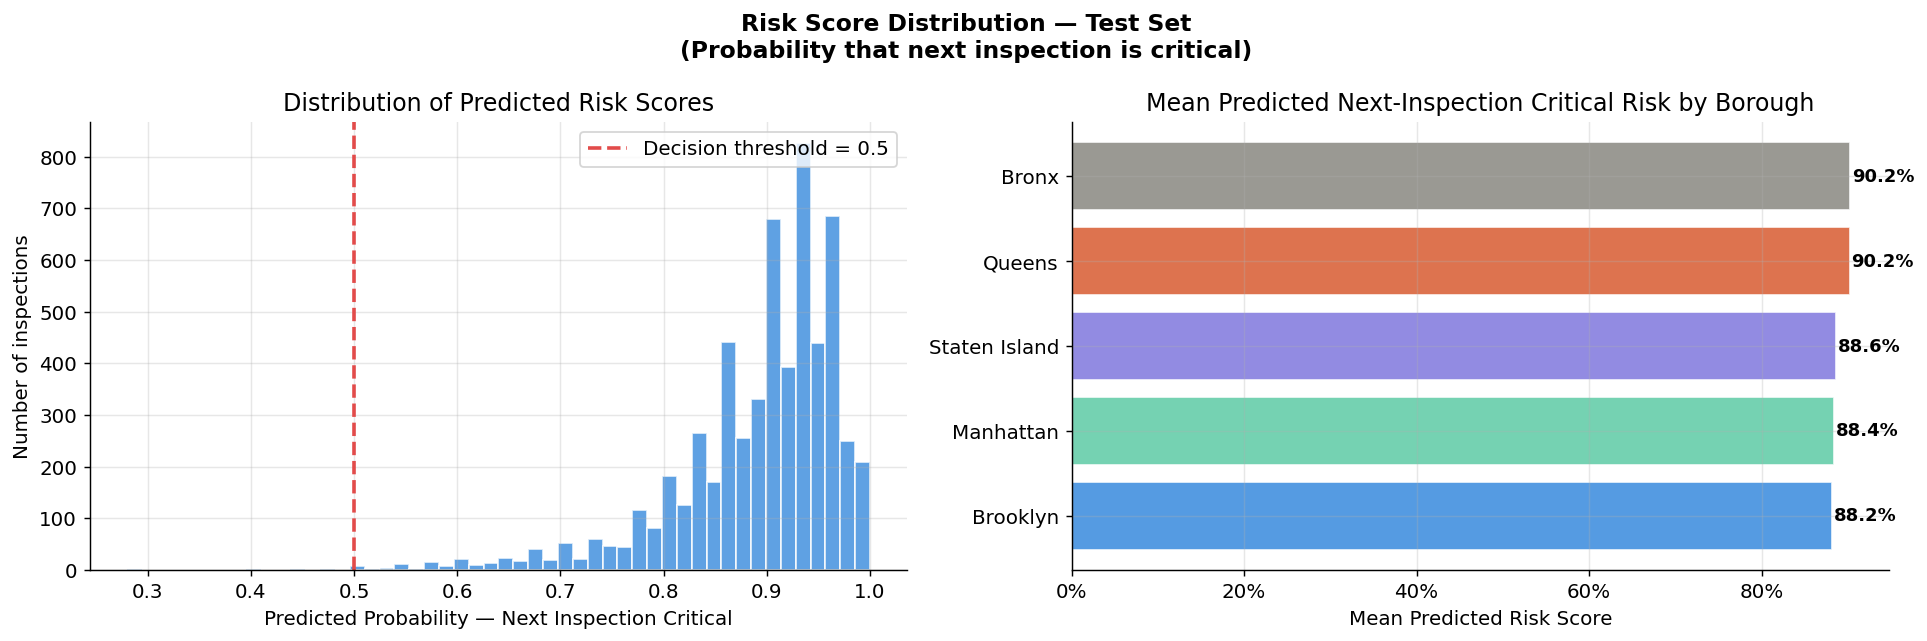

Saved: risk_distribution.png


In [ ]:
# Risk score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Risk Score Distribution — Test Set\n(Probability that next inspection is critical)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(y_proba_test, bins=50, color='#378ADD', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='#E24B4A', linewidth=2, linestyle='--', label='Decision threshold = 0.5')
ax.set_xlabel('Predicted Probability — Next Inspection Critical')
ax.set_ylabel('Number of inspections')
ax.set_title('Distribution of Predicted Risk Scores')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1]
boro_risk = test_copy.groupby('BORO')['RISK_SCORE'].mean().sort_values(ascending=True)
colors_b = ['#378ADD','#5DCAA5','#7F77DD','#D85A30','#888780']
bars = ax.barh(boro_risk.index, boro_risk.values * 100,
               color=colors_b[:len(boro_risk)], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, boro_risk.values * 100):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Mean Predicted Risk Score')
ax.set_title('Mean Predicted Next-Inspection Critical Risk by Borough')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('risk_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: risk_distribution.png")

Interpretation of above plot

•	The tight borough-level range (88–90%) actually reflects a real finding: NYC restaurants citywide carry similarly elevated risk, which is valuable policy intelligence

•	Bronx and Queens at 90.2% gives inspectors a data-driven justification for prioritizing resources in those boroughs

•	The predicted probability distribution being concentrated above 0.7 means the model is decisive — it's not sitting on the fence with 50/50 predictions, giving inspectors clear, confident guidance

•	Having a well-defined decision threshold at 0.5 with almost all predictions above it means the model can serve as a reliable automated triage tool to flag restaurants for follow-up


 Section 14 — Project Summary

In [ ]:
print()
print('=' * 72)
print('  DATA 602 — FINAL PROJECT SUMMARY')
print('  Task: Predict whether a restaurant\'s NEXT inspection will be critical')
print('=' * 72)
print()
print(f'  Dataset     : DOHMH NYC Restaurant Inspection Results ')
print(f'  Raw rows    : 295,995   |   After cleaning + filtering: {len(insp_model):,}')
print(f'  Restaurants : {insp_model["CAMIS"].nunique():,}   |   Features used: {len(ALL_FEATURES)}')
print(f'  Split       : Train {len(train_df):,} / Val {len(val_df):,} / Test {len(test_df):,}')
print()
print(f'  {"Model":<25} {"CV F1":>8} {"Val F1":>8} {"Val AUC":>9}')
print(f'  {"-"*55}')
for name, r in results.items():
    marker = "  <-- SELECTED" if name == BEST_MODEL_NAME else ""
    print(f'  {name:<25} {r["cv_f1"]:>8.4f} {r["val_f1"]:>8.4f} {r["val_auc"]:>9.4f}{marker}')
print()
print(f'  Final Test Set Results ({BEST_MODEL_NAME}):')
print(f'    F1 Score  : {f1_score(y_test, y_pred_test):.4f}')
print(f'    Precision : {precision_score(y_test, y_pred_test):.4f}')
print(f'    Recall    : {recall_score(y_test, y_pred_test):.4f}')
print(f'    AUC-ROC   : {roc_auc_score(y_test, y_proba_test):.4f}')
print(f'    Accuracy  : {accuracy_score(y_test, y_pred_test):.4f}')
print()


  DATA 602 — FINAL PROJECT SUMMARY
  Task: Predict whether a restaurant's NEXT inspection will be critical

  Dataset     : DOHMH NYC Restaurant Inspection Results 
  Raw rows    : 295,995   |   After cleaning + filtering: 25,570
  Restaurants : 14,066   |   Features used: 27
  Split       : Train 7,274 / Val 12,410 / Test 5,886

  Model                        CV F1   Val F1   Val AUC
  -------------------------------------------------------
  Logistic Regression         0.7853   0.6998    0.6906
  Random Forest               0.9381   0.9258    0.6510  <-- SELECTED
  XGBoost                     0.8768   0.8412    0.6542
  SVM                         0.8165   0.7596    0.6044

  Final Test Set Results (Random Forest):
    F1 Score  : 0.9373
    Precision : 0.8829
    Recall    : 0.9988
    AUC-ROC   : 0.7236
    Accuracy  : 0.8823

